In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from chime.calibration import load_CHIME_data
from chime import tv_channels
from chime import util

In [2]:
test_day = "2025_211" #2025_001"
sample_file = f"/home/scratch/dbautist/CHIME_archive/{test_day}"
chime_grid, frequency, timestamps = load_CHIME_data(sample_file)

Text(0, 0.5, 'power [counts]')

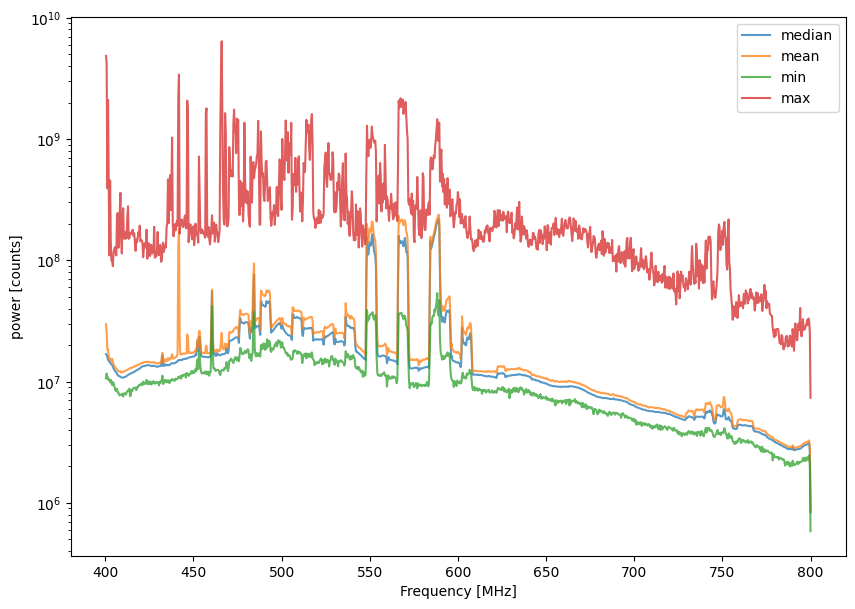

In [3]:
plt.figure(figsize=(10,7))
plt.plot(frequency, np.median(chime_grid, axis=0), label="median", alpha=0.75)
plt.plot(frequency, np.mean(chime_grid, axis=0), label="mean", alpha=0.75)
plt.plot(frequency, np.min(chime_grid, axis=0), label="min", alpha=0.75)
plt.plot(frequency, np.max(chime_grid, axis=0), label="max", alpha=0.75)
plt.legend()
plt.yscale("log")
plt.xlabel("Frequency [MHz]")
plt.ylabel("power [counts]")

In [4]:
def find_freq_indx(target_freq, frequency_axis):
    index = np.argmin(np.abs(frequency_axis - target_freq))
    return index

find_freq_indx(410, frequency)

25

(455.0, 465.0)

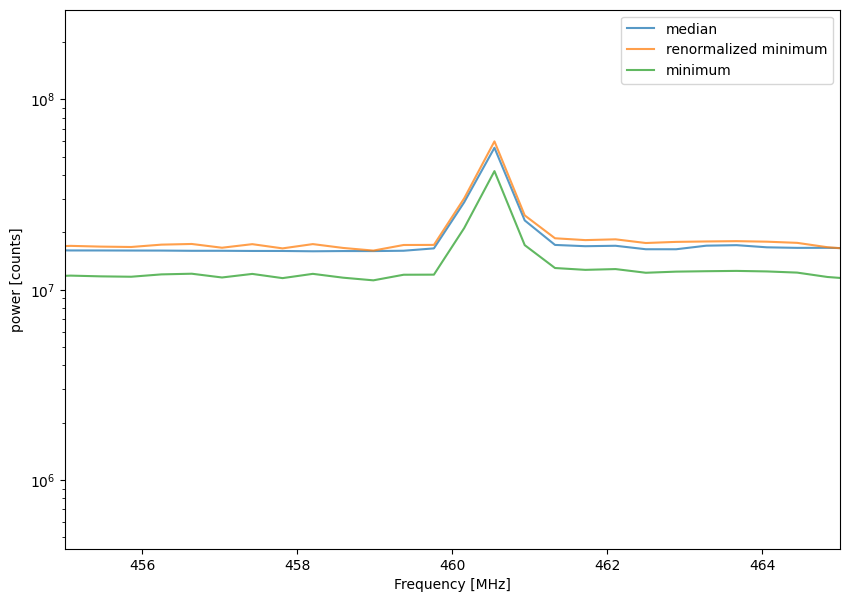

In [5]:
min_spect = np.min(chime_grid, axis=0)
med_spect = np.median(chime_grid, axis=0)

target_index = find_freq_indx(410, frequency)

norm_min = min_spect / min_spect[target_index]
norm_min_to_median = norm_min * med_spect[target_index]


plt.figure(figsize=(10,7))
plt.plot(frequency, med_spect, label="median", alpha=0.75)
plt.plot(frequency, norm_min_to_median, label="renormalized minimum", alpha=0.75)
plt.plot(frequency, min_spect, label="minimum", alpha=0.75)

plt.legend()
plt.yscale("log")
plt.xlabel("Frequency [MHz]")
plt.ylabel("power [counts]")
plt.xlim(455, 465)

(455.0, 465.0)

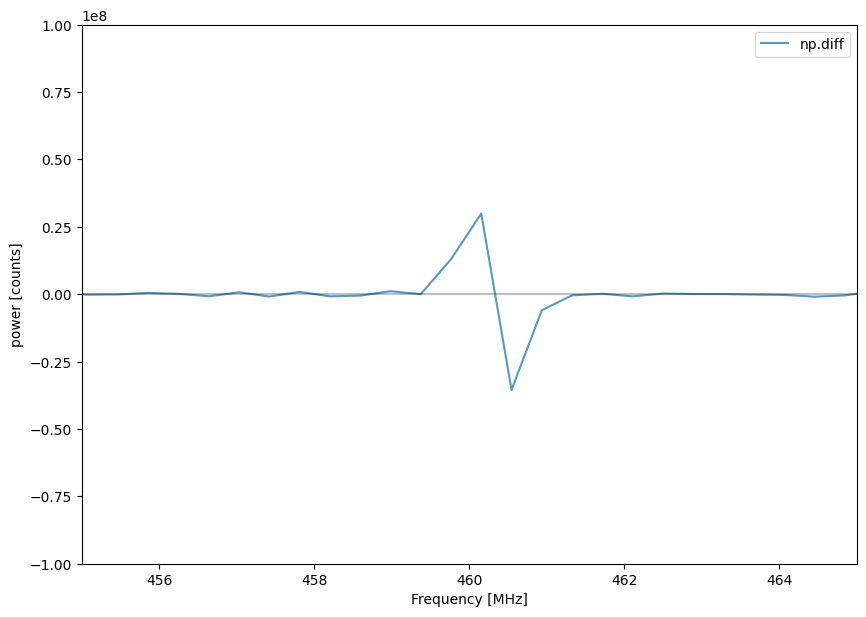

In [6]:
plt.figure(figsize=(10,7))
plt.plot(frequency[:-1], np.diff(norm_min_to_median), label="np.diff", alpha=0.75)
# plt.plot(frequency, norm_min_to_median, label="renormalized minimum", alpha=0.75)
# plt.plot(frequency, min_spect, label="minimum", alpha=0.75)

plt.legend()
# plt.yscale("log")
plt.xlabel("Frequency [MHz]")
plt.ylabel("power [counts]")
plt.ylim(-1e8,
          1e8)
plt.hlines(0, frequency.min(), frequency.max(), color="black", alpha=0.25)
plt.xlim(455, 465)

In [7]:
diff_spectrum = np.diff(norm_min_to_median)
diff_spect_roll=np.roll(diff_spectrum, 1)



In [8]:
def smooth_one_chan(spectrum):
    return

# borrowing some code from Pedro

In [9]:
from astropy.convolution import convolve, Box1DKernel, CustomKernel, Gaussian1DKernel
from scipy.special import iv


def box1d(data, width=64, **kwargs):
    """Smooth data using a box kernel.
    """

    kernel = Box1DKernel(width)
    return convolve(data, kernel, **kwargs)

def gauss1d(data, width=64, **kwargs):
    """Smooth data using a gaussian kernel
    """

    kernel = Gaussian1DKernel(width)
    return convolve(data, kernel, **kwargs)

def digital_filter(f_low, f_hgh, a, nterms):
    """Digital filter. Copied from IDL.

    Parameters
    ----------
    f_low : float
        The lower frequency of the filter as a fraction of the Nyquist frequency.
    f_hgh : float
        The upper frequency of the filter as a fraction of the Nyquist frequency.
    a : float
        The filter power relative to the Gibbs phenomenon wiggles in decibels. 50 is a good choice.
    nterms : int
        The number of terms used to construct the filter.
    
    Returns
    -------
    coefs : list
        Coefficients for the digital filter.
    """

    f_stop = 0.
    if f_hgh < f_low:
        f_stop = 1.

    if a < 20.:
        alpha = 0.
    elif a > 50:
        alpha = 0.1102 * (a - 8.7)
    else:
        alpha = 0.5842 * (a - 21.)**0.4 + 0.07886 * (a - 21.)

    x = np.arange(nterms, dtype=float)
    
    arg = (x + 1.)/nterms
    coef = iv(0, alpha*np.sqrt(1. - arg**2.)) / iv(0, alpha)
    t = (x + 1.)*np.pi
    coef = coef * (np.sin(t*f_hgh) - np.sin(t*f_low))/t
    coef = [coef[::-1], [f_hgh - f_low + f_stop], coef] #REPLICATE IT
    
    return [item for sublist in coef for item in sublist]

def highpass(data, **kwargs):
    """Highpass filter.
    Adapted from the GBT_RFI_pipeline:
    https://github.com/GreenBankObservatory/GBT_RFI_pipeline/blob/master/GBT_RFI_pipeline/scalUtils_wilsonedit.pro
    """

    kwargs.setdefault("normalize_kernel", False)

    ## added lines to correct for interpolation error
    ## Note: it does not flag the VEGAS spurs, so they 
    ##  will show up as RFI. They are quite obvious, because 
    ##  you only see them in one spectral window even when 
    ##  there's overlap between spectral windows.
    kwargs.setdefault("nan_treatment", "fill")
    kwargs.setdefault("fill_value", np.nan)
    kwargs.setdefault("preserve_nan", True)

    filter_coefs = digital_filter(0.1, 1, 200, 64)
    kernel = CustomKernel(filter_coefs)
    
    return convolve(data, kernel, **kwargs)

In [10]:
bad_channels = ["15", "16",  "17", "20", "21", "23", "25", "27", "30", "33", "34", "36", "59", "60"]

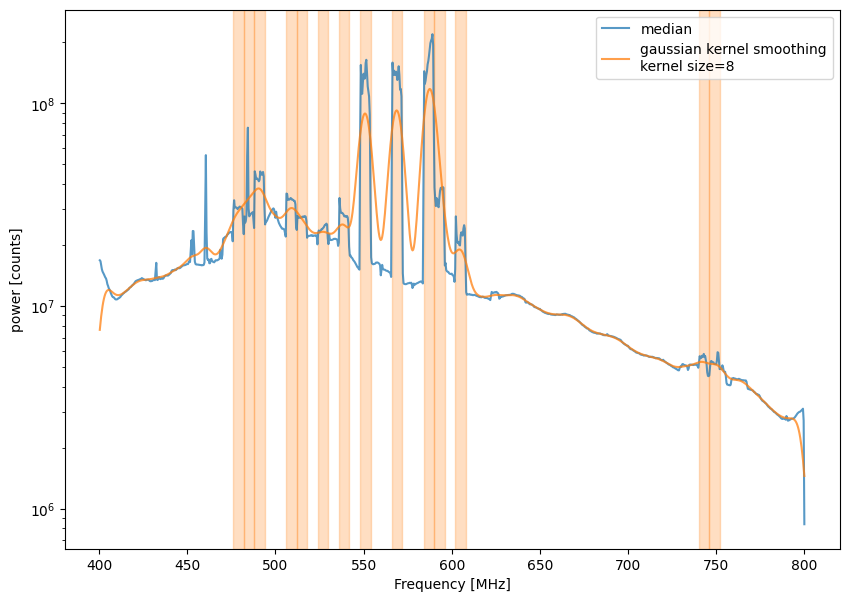

In [11]:
kernel_size = 8
kernel_type = "gauss"

med_smooth = gauss1d(med_spect, width=kernel_size)
highpassed = highpass(med_spect)

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()
ax.plot(frequency, med_spect, label="median", alpha=0.75)
ax.plot(frequency, med_smooth, label=f"gaussian kernel smoothing\nkernel size={kernel_size}", alpha=0.75)
# ax.plot(frequency, highpassed, label="highpass filtered", alpha=0.75)
# ax.plot(frequency, np.mean(chime_grid, axis=0), label="mean", alpha=0.75)
# ax.plot(frequency, np.min(chime_grid, axis=0), label="min", alpha=0.75)
# ax.plot(frequency, np.max(chime_grid, axis=0), label="max", alpha=0.75)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [counts]")

for chan in bad_channels:
    tv_channels.plot_channel(ax, chan)
# tv_channels.plot_channel(ax, "30")
# tv_channels.plot_channel(ax, "33")
# tv_channels.plot_channel(ax, "34")
# tv_channels.plot_channel(ax, "36")

plt.savefig(f"/users/dbautist/CHIME_landing_directory/plots/RFI_removal_test/{kernel_type}_kernel_size_{kernel_size}.png")
plt.show()
plt.close("all")

# Try masking the worst RFI channels

In [12]:
from scipy.interpolate import interp1d

In [13]:
channel_masks = []
padding = 0#0.390625

for bad_chan in bad_channels:
    this_mask = np.where((frequency >= (tv_channels.channel_dict[bad_chan]["lower"] - padding)) & (frequency <= (tv_channels.channel_dict[bad_chan]["upper"] + padding)))
    channel_masks.append(this_mask)

flag_mask = np.unique(np.hstack(channel_masks))
flag_mask


array([194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206,
       207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,
       220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232,
       233, 234, 235, 236, 237, 238, 239, 271, 272, 273, 274, 275, 276,
       277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289,
       290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 317,
       318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330,
       331, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359,
       360, 361, 362, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387,
       388, 389, 390, 391, 392, 393, 424, 425, 426, 427, 428, 429, 430,
       431, 432, 433, 434, 435, 436, 437, 438, 439, 471, 472, 473, 474,
       475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487,
       488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500,
       517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 52

# manually add other bad channel indices

In [14]:
find_freq_indx(554, frequency)
# frequency[153]

393

In [15]:
flag_mask

array([194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206,
       207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,
       220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232,
       233, 234, 235, 236, 237, 238, 239, 271, 272, 273, 274, 275, 276,
       277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289,
       290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 317,
       318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330,
       331, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359,
       360, 361, 362, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387,
       388, 389, 390, 391, 392, 393, 424, 425, 426, 427, 428, 429, 430,
       431, 432, 433, 434, 435, 436, 437, 438, 439, 471, 472, 473, 474,
       475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487,
       488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500,
       517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 52

In [16]:
flag_mask = np.unique(np.hstack(channel_masks))
more_flags = [81, 82, 83, 152, 153, 154, 155, 213, 214, 215, 216, 132, 133, 134, 135, 136, 137, 394, 440, 441, 470, 501, 502, 516]
more_flags = more_flags + list(range(567, 581))

In [17]:
flag_mask = np.hstack([flag_mask, more_flags])

# Use the rejection indices to generate mask to keep data

In [18]:
keep_mask = np.ones(med_spect.shape, dtype=bool)
keep_mask[flag_mask] = False

# frequency[keep_mask]

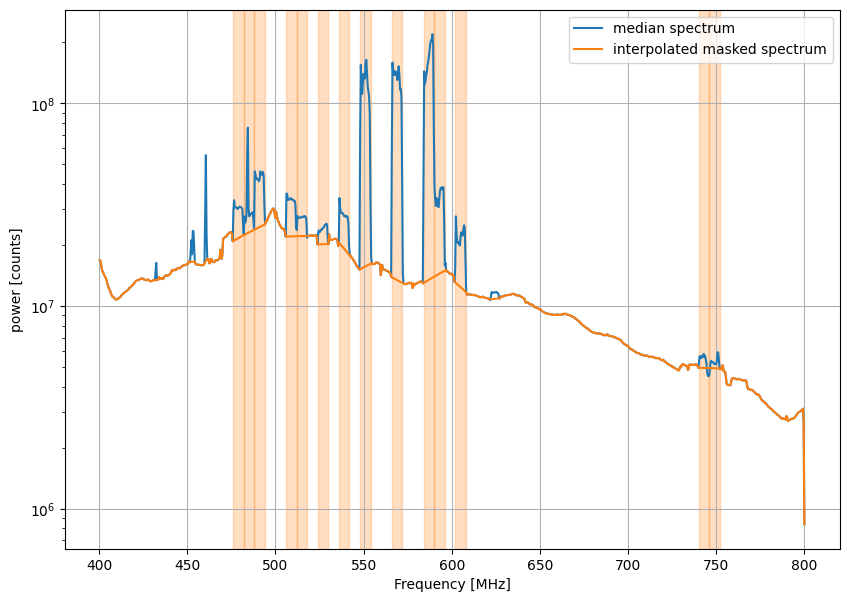

In [19]:
interp_spect = interp1d(frequency[keep_mask], med_spect[keep_mask])

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()

ax.plot(frequency, med_spect, label="median spectrum")
ax.plot(frequency, interp_spect(frequency), label="interpolated masked spectrum")

ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [counts]")

for chan in bad_channels:
    tv_channels.plot_channel(ax, chan)

# tv_channels.plot_channel(ax, "23")

ax.grid()
# ax.set_xlim(500, 550)

# apply smoothing to the masked data

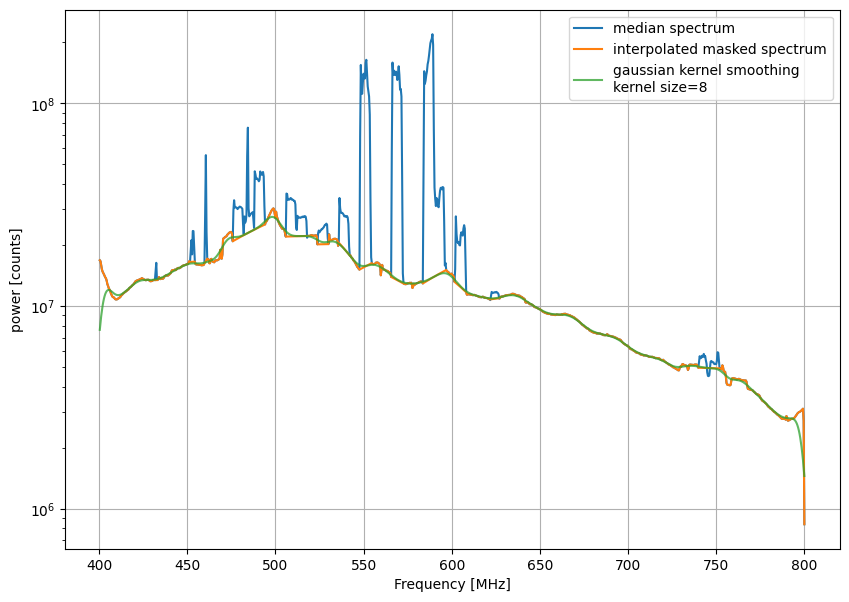

In [20]:
kernel_type = "gaussian"
kernel_size = 8
smoothed_interp = gauss1d(interp_spect(frequency), width=kernel_size)

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()

ax.plot(frequency, med_spect, label="median spectrum")
ax.plot(frequency, interp_spect(frequency), label="interpolated masked spectrum")
ax.plot(frequency, smoothed_interp, label=f"gaussian kernel smoothing\nkernel size={kernel_size}", alpha=0.75)

ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [counts]")

# for chan in bad_channels:
#     tv_channels.plot_channel(ax, chan)

ax.grid()

# recalibrating with interpolated and smoothed spectrum

In [21]:
def usual_calibration(on, off, tsys):
    """
    Equation for the flux of a source from and on/off observation
    pulled directly from Single-Dish Radio Astronomy: Techniques and Applications, 
    Part 3: Calibration and Data Reduction, Single-Dish Calibration Techniques at Radio Wavelengths
    Section 3: System Temperature
    Equation 20:

    T_{source} = [ (T_ON - T_OFF) / T_OFF]

    Arguments:
    ---------------
    on : numpy.ndarray
        Spectrum with the source in the beam. The ON observation
    off : numpy.ndarray
        Spectrum with source NOT in the beam. The OFF observation
    tsys : float
        The known system temperature when observing blank sky

    Returns:
    ---------------
    tsource : numpy.ndarray
        The calibrated spectrum with units of T_sys
    """
    return (on - off) / off * tsys

def tsys(off_cal, on_cal, t_cal):
    """
    Equation for the flux of a source from and on/off observation
    pulled directly from Single-Dish Radio Astronomy: Techniques and Applications, 
    Part 3: Calibration and Data Reduction, Single-Dish Calibration Techniques at Radio Wavelengths
    Section 3: System Temperature
    Equation 22:

    T_{sys} = [ OFFCAL / (ONCAL - OFFCAL) ] * T_cal

    Arguments:
    ---------------
    on_cal : numpy.ndarray
        Spectrum with the known calibrator on. The ONCAL observation
    off_cal : numpy.ndarray
        Spectrum with known calibrator off. The OFFCAL observation
    t_cal : float
        The known system temperature contribution of the calibrator 

    Returns:
    ---------------
    tsource : numpy.ndarray
        The system temperature in units of T_cal
    """
    return off_cal / (on_cal - off_cal) * t_cal

In [28]:
df = pd.read_csv("/users/dbautist/CHIME_landing_directory/calibration_log.csv")
df = df[df["success"] == True]
df

,date,target_freq,target_flux,height,center,width,baseline,sun_projection,success
0,2024_056,410,490000.0,2.639661e+07,1817.148024,12.962662,1.287077e+07,0.515785,True
1,2024_057,410,490000.0,1.872937e+07,1819.617887,12.915378,1.275228e+07,0.521489,True
2,2024_058,410,490000.0,1.724214e+07,1819.617003,13.076639,1.239522e+07,0.527059,True
3,2024_059,410,490000.0,2.869793e+07,1817.565499,12.814123,1.232037e+07,0.532711,True
4,2024_060,410,490000.0,2.291275e+07,1818.107757,13.743389,1.226643e+07,0.538172,True
...,...,...,...,...,...,...,...,...,...
852,2026_179,410,490000.0,9.262307e+07,1915.628955,10.992075,1.202200e+07,0.893802,True
853,2026_180,410,490000.0,1.135966e+08,1917.338103,11.240146,1.230046e+07,0.893393,True
854,2026_181,410,490000.0,8.990388e+07,1915.190833,11.513275,1.236045e+07,0.892899,True
855,2026_182,410,490000.0,1.511172e+08,1916.929733,12.811700,1.239980e+07,0.892377,True


In [29]:
df[df["date"] == test_day]

,date,target_freq,target_flux,height,center,width,baseline,sun_projection,success
518,2025_211,410,490000.0,8.881501e+07,1918.993771,13.303911,1.025398e+07,0.851694,True


In [30]:
tsys = 1.025398e+07 / (8.881501e+07	) * 490000.0
tsys

56572.08393040771

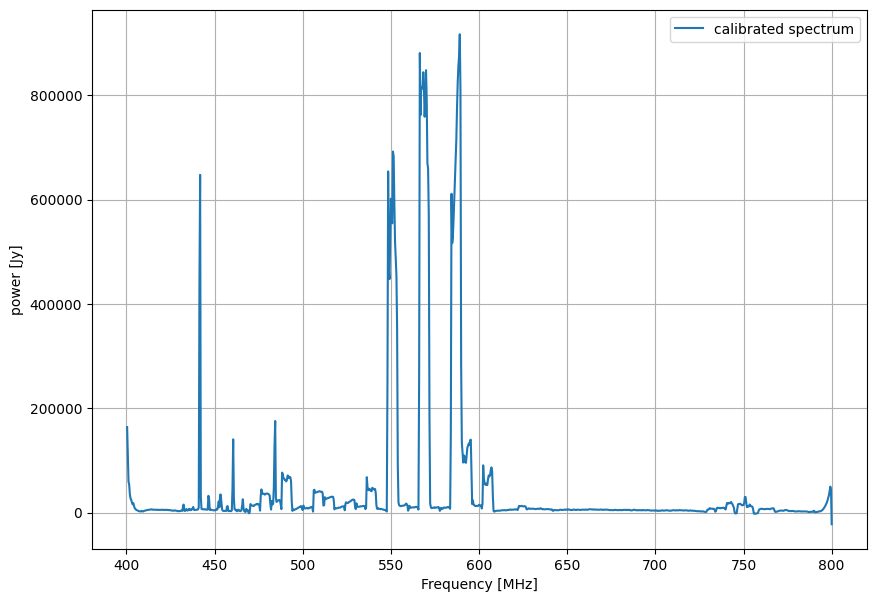

In [31]:
calibrated_spectrum = usual_calibration(np.mean(chime_grid, axis=0), smoothed_interp, 56572.08393040771 )

fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(1,1)
ax = gs.subplots()

ax.plot(frequency, calibrated_spectrum, label="calibrated spectrum")

ax.legend()
# ax.set_yscale("log")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("power [Jy]")
# ax.hlines(0, frequency.min(), frequency.max(), color="black")
ax.grid()

In [32]:
tsys = df["baseline"] / (df["height"]) * df["target_flux"]
tsys

0      238919.877331
1      333626.783941
2      352256.765194
3      210362.868878
4      262323.464526
           ...      
852     63599.512066
853     53058.156991
854     67367.710232
855     40206.539667
856     59689.915744
Length: 823, dtype: float64

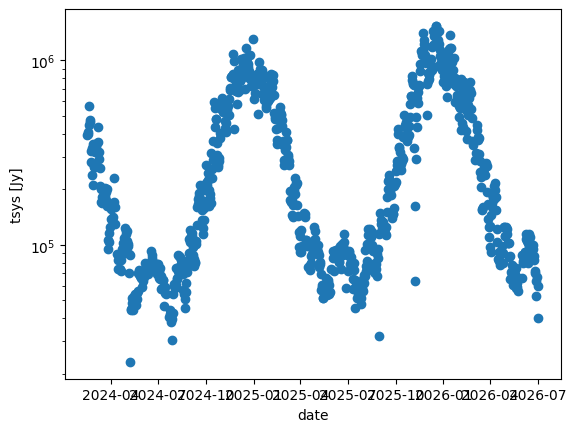

In [33]:
days = []
for i in range(len(df)):
    days.append(util.yyyy_ddd_to_datetime(df.iloc[i]["date"]))

plt.figure()
plt.scatter(days, tsys)
plt.xlabel("date")
plt.ylabel("tsys [Jy]")
# plt.ylim(0, 5e6)
plt.yscale("log")